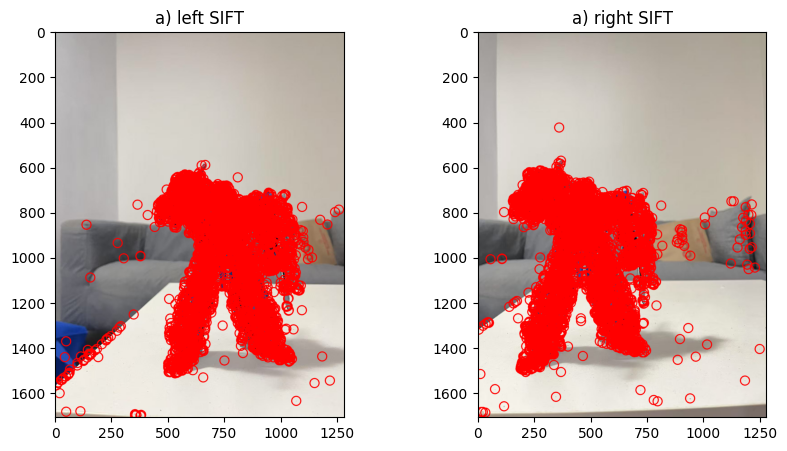

In [87]:
import cv2
import matplotlib.pyplot as plt

# input images (change into gray)
img1 = cv2.imread('left.jpg')
img2 = cv2.imread('right.jpg')
img1_g = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_g = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# Task 1

# sift
sift = cv2.SIFT_create()

# find keypoints
kp1, des1 = sift.detectAndCompute(img1_g, None)
kp2, des2 = sift.detectAndCompute(img2_g, None)


# use .circle instead of .drawKeypoints to draw keypoints
img1_kp = img1.copy()
for kp in kp1:
    x, y = int(kp.pt[0]), int(kp.pt[1])  
    r = 20                     
    cv2.circle(img1_kp, (x, y), r, (0, 0, 255), thickness=3)
    
img2_kp = img2.copy()
for kp in kp2:
    x, y = int(kp.pt[0]), int(kp.pt[1]) 
    r = 20                     
    cv2.circle(img2_kp, (x, y), r, (0, 0, 255), thickness=3)

# show images(change in to RGB)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img1_kp, cv2.COLOR_BGR2RGB)), plt.title('a) left SIFT')
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(img2_kp, cv2.COLOR_BGR2RGB)), plt.title('a) right SIFT')
plt.show()

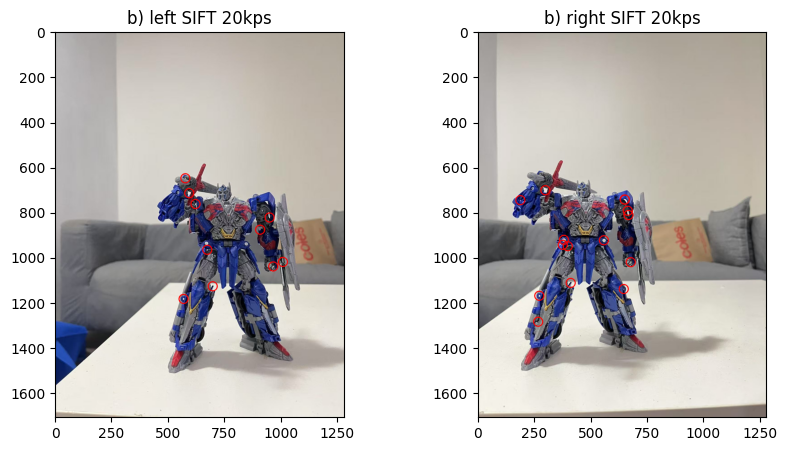

Use method "nfeatures=20" when creating sift.
The method can sort all the keypoints and keep the most obvious 20 keypoints and cut the others


In [99]:
# sift: reduce into 20
sift_20 = cv2.SIFT_create(nfeatures=20)

# find keypoints
kp1_20, des1_20 = sift_20.detectAndCompute(img1_g, None)
kp2_20, des2_20 = sift_20.detectAndCompute(img2_g, None)


# use .circle instead of .drawKeypoints to draw keypoints
img1_kp_20 = img1.copy()
for kp1 in kp1_20:
    x1, y1 = int(kp1.pt[0]), int(kp1.pt[1])  
    r1 = 20                     
    cv2.circle(img1_kp_20, (x1, y1), r1, (0, 0, 255), thickness=3)
    
img2_kp_20 = img2.copy()
for kp2 in kp2_20:
    x2, y2 = int(kp2.pt[0]), int(kp2.pt[1]) 
    r2 = 20                     
    cv2.circle(img2_kp_20, (x2, y2), r2, (0, 0, 255), thickness=3)

# show images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(img1_kp_20, cv2.COLOR_BGR2RGB)), plt.title('b) left SIFT 20kps')
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(img2_kp_20, cv2.COLOR_BGR2RGB)), plt.title('b) right SIFT 20kps')
plt.show()

print('Use method "nfeatures=20" when creating sift.\nThe method can sort all the keypoints and keep the most obvious 20 keypoints and cut the others')

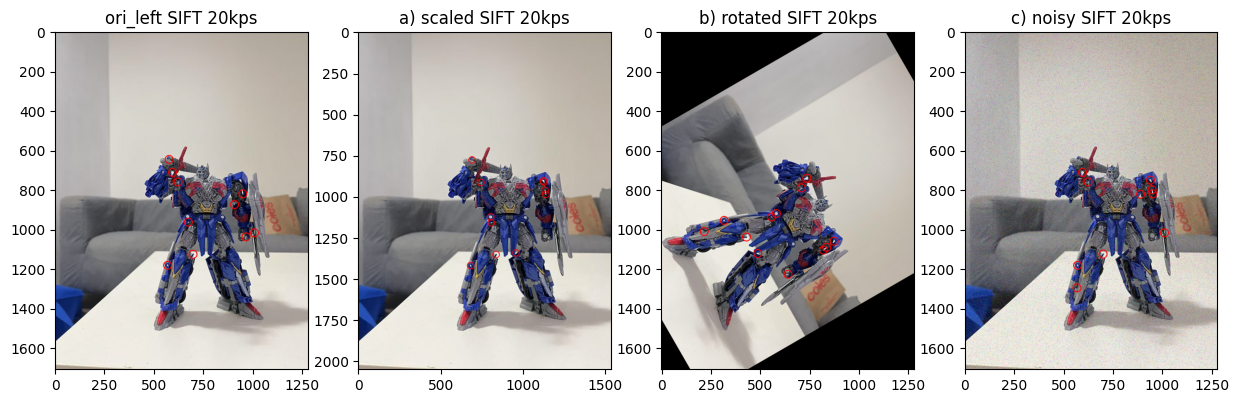

The chosen keypoints for a, b, c is roughly the same.
The rotated image shows the best robust, and the noisy image is the worst


In [104]:
# Task 2
from skimage.util import random_noise
import numpy as np

# Scale
scaled_left_img = cv2.resize(img1_g, None, fx=1.2, fy=1.2, interpolation=cv2.INTER_LINEAR)
scaled_left_img_ori = cv2.resize(img1, None, fx=1.2, fy=1.2, interpolation=cv2.INTER_LINEAR)
kp1_20_sc, des1_sc = sift_20.detectAndCompute(scaled_left_img, None)

# Rotate
(h, w) = img1_g.shape[:2]
center = (w // 2, h // 2)
M = cv2.getRotationMatrix2D(center, -60, 1.0)  # rotate 60d
rotated_left_img = cv2.warpAffine(img1_g, M, (w, h))
rotated_left_img_ori = img1.copy() # rotate the origin RGB image for next step
rotated_left_img_ori = cv2.warpAffine(rotated_left_img_ori, M, (w, h))
kp1_20_rt, des1_rt = sift_20.detectAndCompute(rotated_left_img, None)

# Noise
noisy_left_img = random_noise(img1, mode='s&p', amount=0.05)  # add random noise in RGB image(change into float64)
noisy_left_img = (255 * noisy_left_img).astype(np.uint8) # change float64 into uint8 to fix (0, 1) to (0, 255)
noisy_left_img_g = cv2.cvtColor(noisy_left_img, cv2.COLOR_BGR2GRAY) # change int gray to do sift
kp1_20_ns, des1_ns = sift_20.detectAndCompute(noisy_left_img_g, None)

# use .circle instead of .drawKeypoints to draw keypoints
for kp in kp1_20_sc:
    x, y = int(kp.pt[0]), int(kp.pt[1])  
    r = 20                     
    cv2.circle(scaled_left_img_ori, (x, y), r, (0, 0, 255), thickness=3)

for kp in kp1_20_rt:
    x, y = int(kp.pt[0]), int(kp.pt[1])  
    r = 20                     
    cv2.circle(rotated_left_img_ori, (x, y), r, (0, 0, 255), thickness=3)

for kp in kp1_20_ns:
    x, y = int(kp.pt[0]), int(kp.pt[1])  
    r = 20                     
    cv2.circle(noisy_left_img, (x, y), r, (0, 0, 255), thickness=3)

# show image
plt.figure(figsize=(15,8))
plt.subplot(1,4,1), plt.imshow(cv2.cvtColor(img1_kp_20, cv2.COLOR_BGR2RGB)), plt.title('ori_left SIFT 20kps')
plt.subplot(1,4,2), plt.imshow(cv2.cvtColor(scaled_left_img_ori, cv2.COLOR_BGR2RGB)), plt.title('a) scaled SIFT 20kps')
plt.subplot(1,4,3), plt.imshow(cv2.cvtColor(rotated_left_img_ori, cv2.COLOR_BGR2RGB)), plt.title('b) rotated SIFT 20kps')
plt.subplot(1,4,4), plt.imshow(cv2.cvtColor(noisy_left_img, cv2.COLOR_BGR2RGB)), plt.title('c) noisy SIFT 20kps')
plt.show()

print('The chosen keypoints for a, b, c is roughly the same.\nThe rotated image shows the best robust, and the noisy image is the worst')

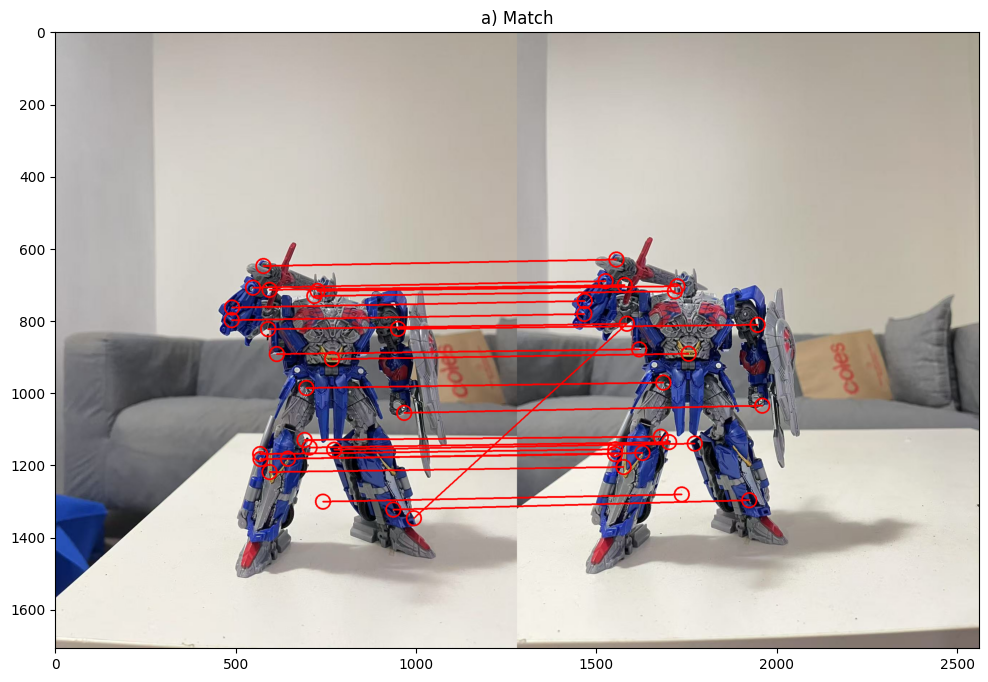

In [154]:
# Task 3
# sift: reduce into 100 for better mapping
sift_m = cv2.SIFT_create(nfeatures = 100)

# find keypoints
kp1_m, des1_m = sift_m.detectAndCompute(img1_g, None)
kp2_m, des2_m = sift_m.detectAndCompute(img2_g, None)

# match kps
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1_m, des2_m, k=2)
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance: #search for good match
        good_matches.append(m)
img_matches = cv2.drawMatches(img1, kp1_m, img2, kp2_m, good_matches, None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# draw 2 images in 1 canvas
h1, w1, _ = img1.shape
h2, w2, _ = img2.shape
canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
canvas[:h1, :w1, :] = img1
canvas[:h2, w1:w1 + w2, :] = img2

# draw circles and lines
for match in good_matches:
    # img1 kps
    x1, y1 = kp1_m[match.queryIdx].pt
    # img2 kps + img1's width
    x2, y2 = kp2_m[match.trainIdx].pt
    x2 += w1
    # method circle needs int data
    x1, y1 = int(x1), int(y1)
    x2, y2 = int(x2), int(y2)

    # draw circle
    cv2.circle(canvas, (x1, y1), 20, (0, 0, 255), thickness=3)
    cv2.circle(canvas, (x2, y2), 20, (0, 0, 255), thickness=3)
    
    # draw lines
    cv2.line(canvas, (x1, y1), (x2, y2), (0, 0, 255), thickness=3)

# show image
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.title('a) Match')
plt.show()

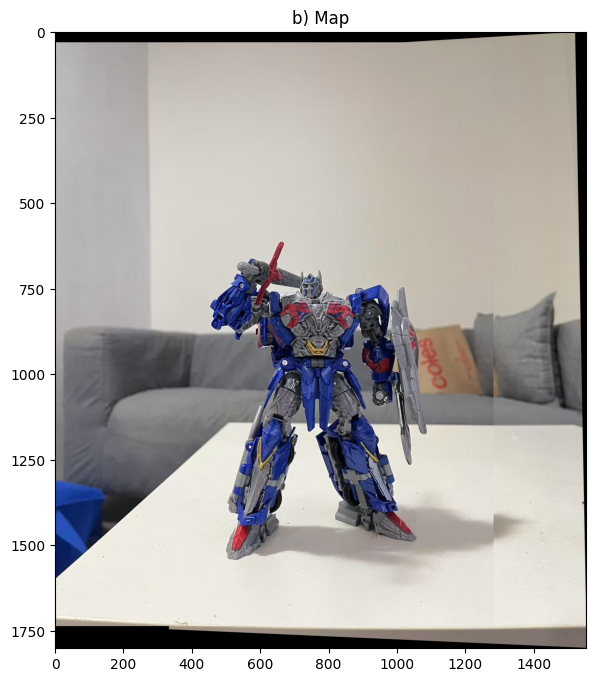

In [152]:
# if numbers of match points less then 10 will lead to errors
if len(good_matches) > 10:
    # set the matched points
    src_pts = np.float32([kp2_m[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp1_m[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)

    # RANSAC
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    # stretching img2's vertics and caculate the scale
    pts_img2 = np.float32([[0,0], [0,h2], [w2,h2], [w2,0]]).reshape(-1,1,2)
    dst_img2 = cv2.perspectiveTransform(pts_img2, H) # stretch by the rusult of RANSAC

    # caculate the scale of the canvas
    pts_img1 = np.float32([[0,0], [0,h1], [w1,h1], [w1,0]]).reshape(-1,1,2)
    points = np.concatenate((dst_img2, pts_img1), axis=0)

    [xmin, ymin] = np.int32(points.min(axis=0).ravel() - 0.5)
    [xmax, ymax] = np.int32(points.max(axis=0).ravel() + 0.5)

    translation = np.array([[1, 0, -xmin],
                            [0, 1, -ymin],
                            [0, 0, 1]])

    result_width = xmax - xmin
    result_height = ymax - ymin

    # stretch and draw image2 on canvas
    warped_img2 = cv2.warpPerspective(img2, translation.dot(H), (result_width, result_height))

    # put image1 above image2 on canvas
    result = warped_img2.copy()
    result[-ymin:h1 - ymin, -xmin:w1 - xmin] = img1

    # show image
    plt.figure(figsize=(15,8))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title('b) Map')
    plt.show()

else:
    print("num of match points less then 10")
